**Sparse overcomplete autoencoder for representing features learned by the mlp.**

In [8]:
import torch.nn as nn
import torch
from sae import SparseOvercompleteAutoencoder


**Training sparse autoencoder**

In [3]:
saved = torch.load("activations for 128 model size/encoder_mlp_acts.pt", weights_only=False)
activations = saved["acts"] if isinstance(saved, dict) else saved

sae = SparseOvercompleteAutoencoder(128, 1024)
sae.normalize_decoder_()
opt = torch.optim.Adam(sae.parameters(), lr=1e-3)

for step in range(2000):
    batch = activations[torch.randint(0, activations.size(0), (512,))]
    x_hat, z = sae(batch)
    loss = sae.loss(batch, x_hat, z)
    opt.zero_grad()
    loss.backward()
    opt.step()
    sae.normalize_decoder_()

    if step % 100 == 0:
        print(f"Step {step}, Loss: {loss.item()}")

torch.save(sae.state_dict(), "activations for 128 model size/sae.pt")
print("just saved to activations for 128 model size/sae.pt")


Step 0, Loss: 14.988234519958496
Step 100, Loss: 0.8068925738334656
Step 200, Loss: 0.5008713006973267
Step 300, Loss: 0.40364912152290344
Step 400, Loss: 0.3767549991607666
Step 500, Loss: 0.3641270697116852
Step 600, Loss: 0.35810837149620056
Step 700, Loss: 0.3478226959705353
Step 800, Loss: 0.33617475628852844
Step 900, Loss: 0.32843413949012756
Step 1000, Loss: 0.32391318678855896
Step 1100, Loss: 0.3202410936355591
Step 1200, Loss: 0.3143390715122223
Step 1300, Loss: 0.30576232075691223
Step 1400, Loss: 0.3101900815963745
Step 1500, Loss: 0.3058182895183563
Step 1600, Loss: 0.3057101368904114
Step 1700, Loss: 0.29906097054481506
Step 1800, Loss: 0.29223889112472534
Step 1900, Loss: 0.2915971279144287
just saved to activations for 128 model size/sae.pt


In [4]:
import torch
import matplotlib.pyplot as plt
from sae import SparseOvercompleteAutoencoder

ACTS_PATH = "activations for 128 model size/encoder_mlp_acts.pt"
SAE_PATH = "activations for 128 model size/sae.pt"
MODEL_PATH = "activations for 128 model size/model_1.pt"
SEQ_LEN = 10

saved = torch.load(ACTS_PATH, weights_only=False)
acts, tokens, positions = saved["acts"], saved["tokens"], saved["positions"]

sae = SparseOvercompleteAutoencoder(128, 1024)
sae.load_state_dict(torch.load(SAE_PATH, weights_only=True))
sae.eval()

with torch.no_grad():
    x_hat, z = sae(acts)

decoder = sae.W_dec.weight.detach()
decoder = decoder / decoder.norm(dim=0, keepdim=True).clamp(min=1e-8)

model_sd = torch.load(MODEL_PATH, weights_only=False)
embed = model_sd["src_embed.0.lut.weight"].detach()
embed_hat = embed / embed.norm(dim=1, keepdim=True).clamp(min=1e-8)
unembed = model_sd["generator.proj.weight"].detach()

fired = z > 0
freq = fired.float().mean(0)
l0 = fired.sum(1).float()
explained = 1 - (acts - x_hat).pow(2).sum() / (acts - acts.mean(0)).pow(2).sum()

tok_ids = list(range(1, 11))
mean_on_token = torch.stack([z[tokens == t].mean(0) for t in tok_ids])
share = mean_on_token / mean_on_token.sum(0).clamp(min=1e-8)
preferred = share.argmax(0)  # index into tok_ids
selectivity = share.max(0).values
mean_on_pos = torch.stack([z[positions == p].mean(0) for p in range(SEQ_LEN)])
pos_share = mean_on_pos / mean_on_pos.sum(0).clamp(min=1e-8)
pos_selectivity = pos_share.max(0).values
enough = fired.sum(0) >= 30

print(f"tokens {acts.shape[0]}   features {z.shape[1]}")
print(f"explained variance {explained.item():.3f}")
print(f"mean L0 {l0.mean().item():.2f}   (features on at a typical token)")
print(f"dead features {(freq == 0).sum().item()} / {freq.numel()}")
print(f"features with at least 30 activations {enough.sum().item()}")
print(f"of those, ≥80% of activation mass on one token {(enough & (selectivity >= 0.8)).sum().item()}")

tokens 30000   features 1024
explained variance 0.994
mean L0 10.38   (features on at a typical token)
dead features 565 / 1024
features with at least 30 activations 136
of those, ≥80% of activation mass on one token 107


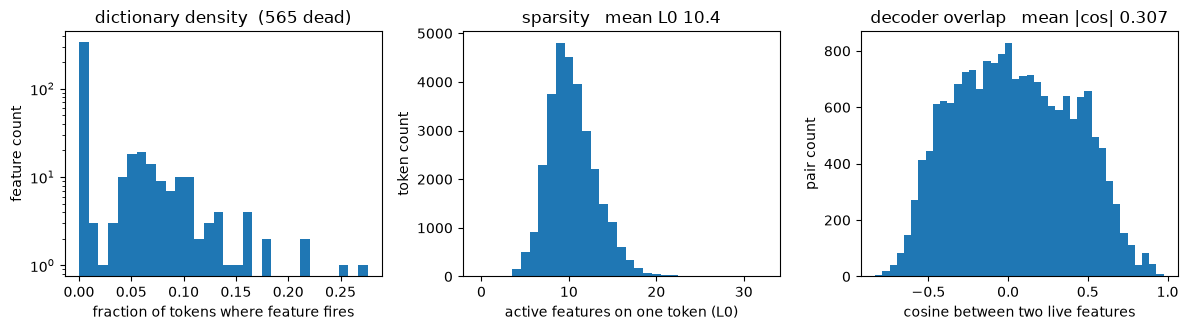

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))

live = freq[freq > 0].numpy()
axes[0].hist(live, bins=30)
axes[0].set_yscale("log")
axes[0].set_xlabel("fraction of tokens where feature fires")
axes[0].set_ylabel("feature count")
axes[0].set_title(f"dictionary density  ({(freq == 0).sum().item()} dead)")

axes[1].hist(l0.numpy(), bins=range(0, int(l0.max()) + 2), align="left")
axes[1].set_xlabel("active features on one token (L0)")
axes[1].set_ylabel("token count")
axes[1].set_title(f"sparsity   mean L0 {l0.mean().item():.1f}")


live_ids = torch.where(enough)[0]
gram = decoder[:, live_ids].T @ decoder[:, live_ids]
off = gram[~torch.eye(gram.shape[0], dtype=torch.bool)]
axes[2].hist(off.numpy(), bins=40)
axes[2].set_xlabel("cosine between two live features")
axes[2].set_ylabel("pair count")
axes[2].set_title(f"decoder overlap   mean |cos| {off.abs().mean().item():.3f}")

fig.tight_layout()
plt.show()

feature 885   fires on 15.1% of tokens   token selectivity 1.00   position selectivity 0.82
 8.12  [1] 7 7 5 3 2 6 7 2 8
 8.11  [1] 7 3 5 7 3 8 5 6 1
 8.07  [1] 2 5 3 9 3 2 7 7 7
 8.05  [1] 2 7 5 3 9 6 6 9 8

feature 174   fires on 10.4% of tokens   token selectivity 0.96   position selectivity 0.26
11.03  1 10 6 8 10 5 6 1 [2] 9
11.01  1 9 9 6 6 10 5 3 [2] 2
10.99  1 6 1 6 3 5 8 1 [2] 5
10.96  1 9 5 1 6 10 2 3 [2] 5

feature 949   fires on 8.5% of tokens   token selectivity 0.98   position selectivity 0.29
 8.47  1 7 5 3 1 [3] 9 9 4 10
 8.36  1 10 9 1 7 [3] 4 5 3 4
 8.36  1 9 7 1 5 [3] 8 4 1 9
 8.34  1 9 1 4 3 [3] 5 7 4 7

feature 409   fires on 10.7% of tokens   token selectivity 0.86   position selectivity 0.35
 9.45  1 4 1 5 [4] 7 5 7 1 7
 9.33  1 1 4 9 [4] 6 7 8 5 7
 9.32  1 6 1 8 [4] 7 5 2 7 7
 9.30  1 1 4 9 [4] 5 7 8 2 7

feature 421   fires on 11.3% of tokens   token selectivity 0.93   position selectivity 0.34
 7.44  1 9 2 9 3 6 4 9 [5] 2
 7.37  1 3 6 6 2 2 2 9 [5] 10
 7.33  1

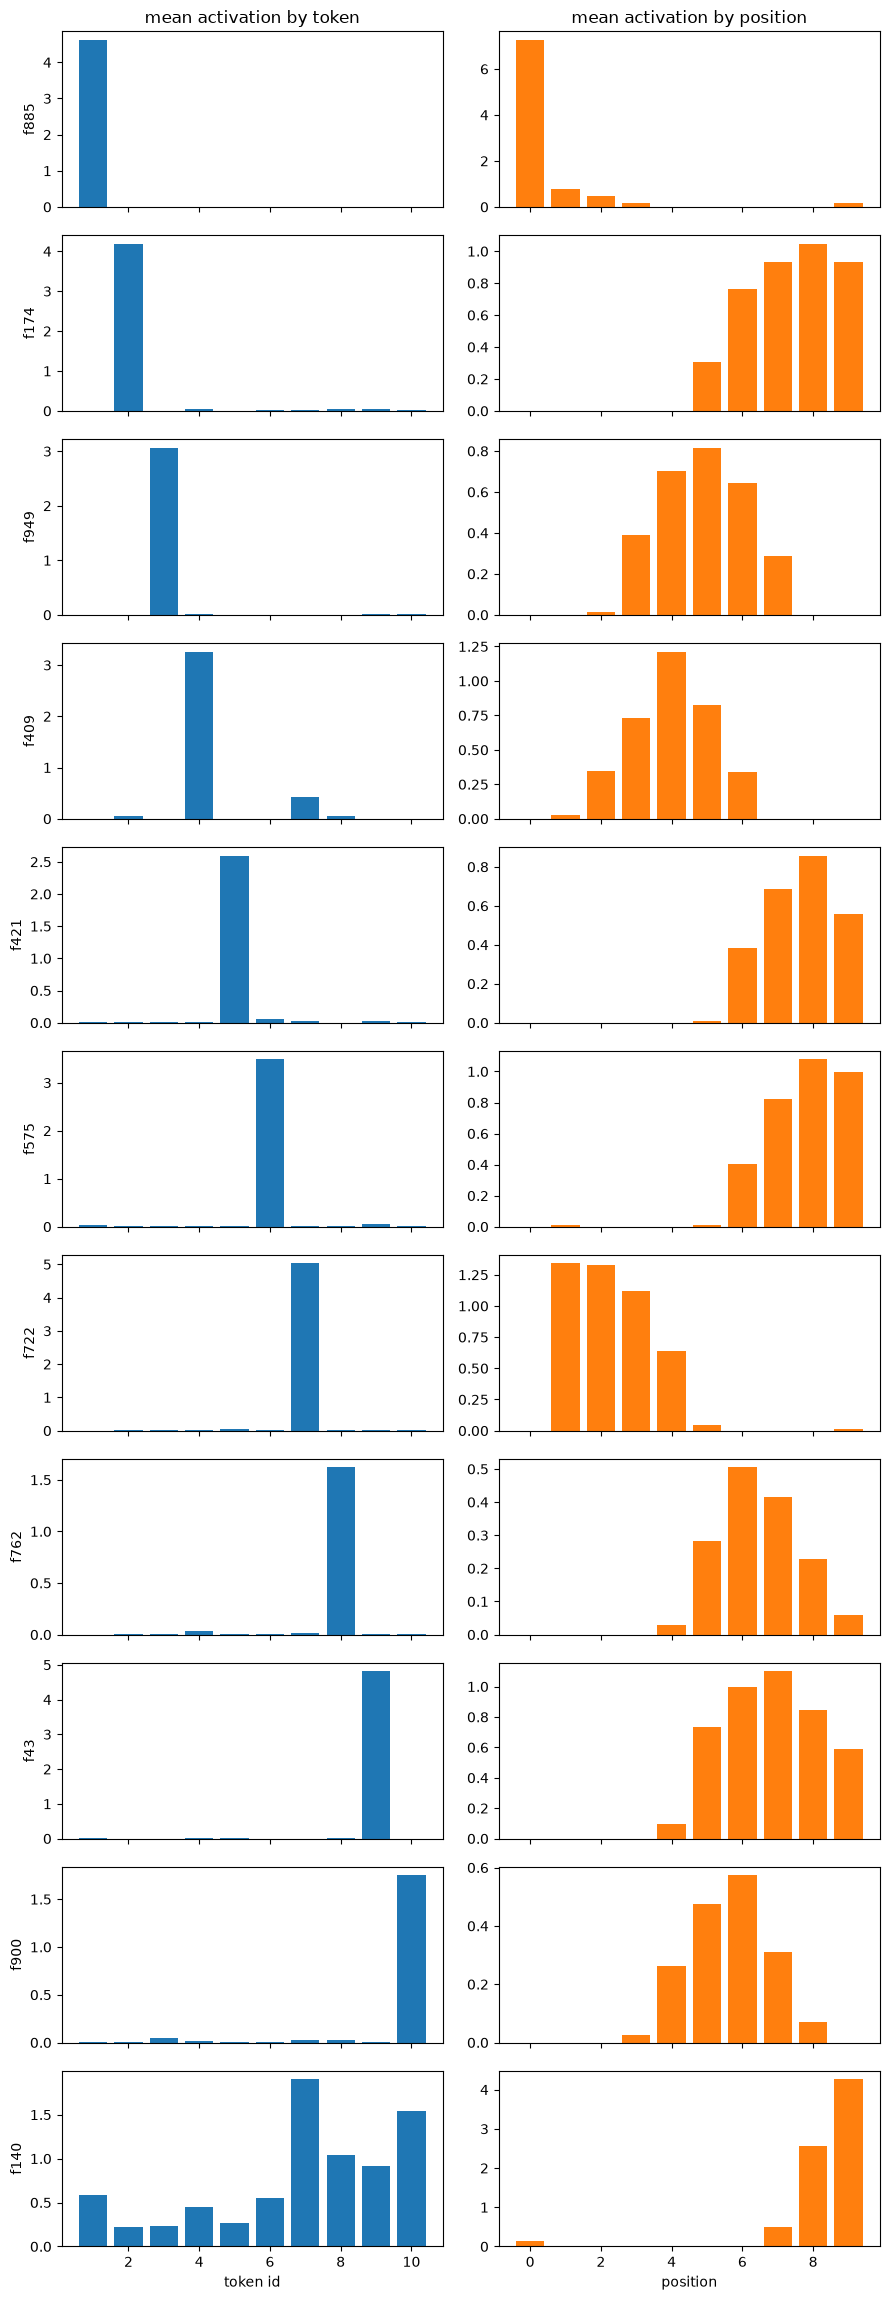

In [6]:
def representative_features(min_selectivity=0.8):
    chosen = []
    for ti in range(len(tok_ids)):
        candidates = torch.where(enough & (preferred == ti) & (selectivity >= min_selectivity))[0]
        if len(candidates) == 0:
            continue
        chosen.append(candidates[freq[candidates].argmax()].item())
    position_features = torch.where(enough & (pos_selectivity > 0.5) & (selectivity < 0.4))[0]
    if len(position_features):
        chosen.append(position_features[freq[position_features].argmax()].item())
    return chosen


def top_contexts(feature, k=4):
    idx = z[:, feature].argsort(descending=True)[:k]
    rows = []
    for i in idx.tolist():
        start = (i // SEQ_LEN) * SEQ_LEN
        seq = tokens[start : start + SEQ_LEN].tolist()
        pos = i - start
        rows.append((z[i, feature].item(), pos, seq))
    return rows


def show_dashboard(feature_ids):
    """Per feature: which token it fires on, which position, and the strongest sequences.

    The bracketed token is the position that produced the activation. Read the
    two bars together. A tall bar on one token is a token detector. A tall bar
    on one position and a flat token plot is a position detector.
    """
    n = len(feature_ids)
    fig, axes = plt.subplots(n, 2, figsize=(9, 2.1 * n), sharex="col")
    if n == 1:
        axes = axes.reshape(1, 2)

    for row, feature in enumerate(feature_ids):
        axes[row, 0].bar(tok_ids, mean_on_token[:, feature].numpy(), color="C0")
        axes[row, 0].set_ylabel(f"f{feature}")
        axes[row, 1].bar(range(SEQ_LEN), mean_on_pos[:, feature].numpy(), color="C1")
        if row == 0:
            axes[row, 0].set_title("mean activation by token")
            axes[row, 1].set_title("mean activation by position")

        contexts = top_contexts(feature)
        rendered = []
        for value, pos, seq in contexts:
            marked = [f"[{t}]" if j == pos else str(t) for j, t in enumerate(seq)]
            rendered.append(f"{value:5.2f}  " + " ".join(marked))
        print(
            f"feature {feature}   fires on {freq[feature].item():.1%} of tokens   "
            f"token selectivity {selectivity[feature].item():.2f}   "
            f"position selectivity {pos_selectivity[feature].item():.2f}\n"
            + "\n".join(rendered)
            + "\n"
        )

    axes[-1, 0].set_xlabel("token id")
    axes[-1, 1].set_xlabel("position")
    fig.tight_layout()
    plt.show()


reps = representative_features()
show_dashboard(reps)

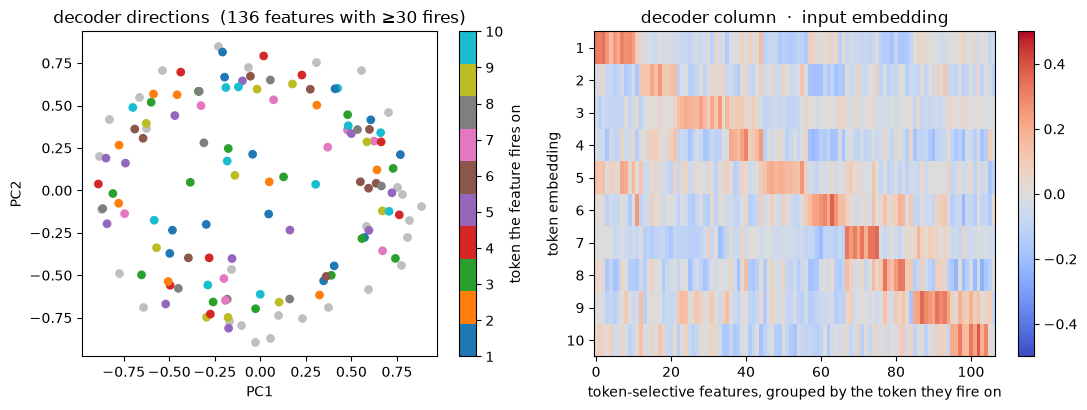

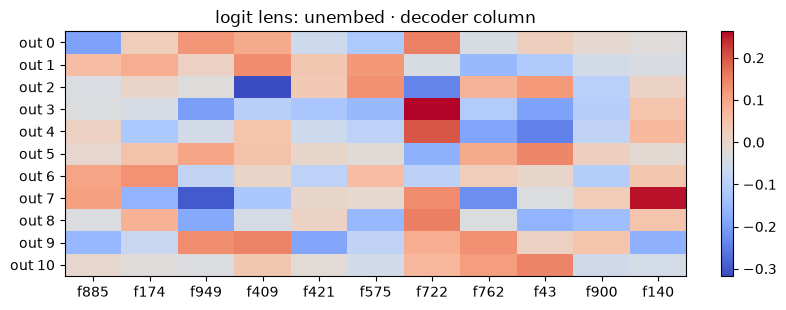

In [7]:
X = decoder[:, live_ids].T
Xc = X - X.mean(0)
U, S, _ = torch.linalg.svd(Xc, full_matrices=False)
xy = (U[:, :2] * S[:2]).numpy()
color = preferred[live_ids].numpy()
pure = (selectivity[live_ids] >= 0.8).numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(xy[~pure, 0], xy[~pure, 1], c="0.75", s=28, label="not token-selective")
sc = axes[0].scatter(xy[pure, 0], xy[pure, 1], c=color[pure], cmap="tab10", s=28, vmin=0, vmax=9)
axes[0].set_title(f"decoder directions  ({len(live_ids)} features with ≥30 fires)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
cbar = fig.colorbar(sc, ax=axes[0], ticks=range(10))
cbar.ax.set_yticklabels(tok_ids)
cbar.set_label("token the feature fires on")


pure_ids = live_ids[selectivity[live_ids] >= 0.8]
pure_color = preferred[pure_ids].numpy()
order = sorted(range(len(pure_ids)), key=lambda i: (int(pure_color[i]), -freq[pure_ids[i]].item()))
cos = (embed_hat @ decoder[:, pure_ids]).numpy()
shown = cos[1:, order]  # drop padding token 0
im = axes[1].imshow(shown, aspect="auto", cmap="coolwarm", vmin=-0.5, vmax=0.5)
axes[1].set_yticks(range(10), tok_ids)
axes[1].set_xlabel("token-selective features, grouped by the token they fire on")
axes[1].set_ylabel("token embedding")
axes[1].set_title("decoder column  ·  input embedding")
fig.colorbar(im, ax=axes[1], fraction=0.046)
fig.tight_layout()
plt.show()


logits = unembed @ decoder[:, reps]
fig, ax = plt.subplots(figsize=(8, 3.2))
im = ax.imshow(logits.numpy(), aspect="auto", cmap="coolwarm")
ax.set_yticks(range(logits.shape[0]), [f"out {t}" for t in range(logits.shape[0])])
ax.set_xticks(range(len(reps)), [f"f{f}" for f in reps])
ax.set_title("logit lens: unembed · decoder column")
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()